# Metaheuristics

A heuristic is a practical approach to solving computational problems that prioritises speed and efficiency over a guarantee of finding the optimal result. For difficult combinatorial or NP-hard problems, determining the exact extremum of an objective function using exhaustive search or gradient-based algorithms may be infeasible because of enormous time complexity. A heuristic follows predefined rules that guide the search through the solution space. Its main purpose is to produce a result that is "good enough" — i.e. close to the optimum — within an acceptable amount of time.

A particular advantage of heuristic methods is their high flexibility and robustness to mathematical properties such as a lack of differentiability or continuity of the objective function. Whereas classical algorithms designed for specific problems exploit detailed knowledge of the problem structure, metaheuristics (e.g. evolutionary algorithms) provide general computational frameworks. They combine exploration (searching new areas of the solution space) with exploitation (improving promising states that have already been found), which helps prevent premature trapping in local optima. The price of this flexibility is the absence of a precise error estimate and the need to tune the algorithm's control parameters carefully.

## Evolutionary algorithms

Evolutionary algorithms are a broad family of general-purpose search and optimisation metaheuristics inspired by fundamental mechanisms of biological evolution. At the heart of these methods is the Darwinian idea of natural selection: weaker individuals are more likely to be eliminated, while individuals better adapted to the environment have a greater probability of surviving and passing their characteristics to subsequent generations. This process is driven by inheritance and by the continual introduction of new genetic variation through mutation and the exchange of genetic material.

## Genetic algorithms

Genetic algorithms are the most widely used subclass of evolutionary algorithms. Their distinguishing feature is a clear separation between the genotype (the encoded representation of a solution) and the phenotype (the corresponding concrete solution in the problem space). While general evolutionary algorithms may operate directly on problem-domain data structures, genetic algorithms place particular emphasis on explicit crossover and mutation operators applied to the encoded genome, with a fitness function serving as the analogue of environmental selection pressure.

> Nature-inspired computation extends beyond biological and genetic evolution and also includes swarm-intelligence methods. These methods are inspired by the collective, self-organising behaviour of populations such as schools of fish, flocks of birds, or social insects. Common approaches include:
> - Particle Swarm Optimisation (PSO),
> - bee-inspired algorithms (e.g. Artificial Bee Colony — ABC),
> - Ant Colony Optimisation (ACO).
>
> Although swarm algorithms do not use classical genetic operators such as crossover and mutation, they share the same basic philosophy as evolutionary algorithms: they operate on a population of candidate solutions and use simple local rules to produce complex, globally effective behaviour.

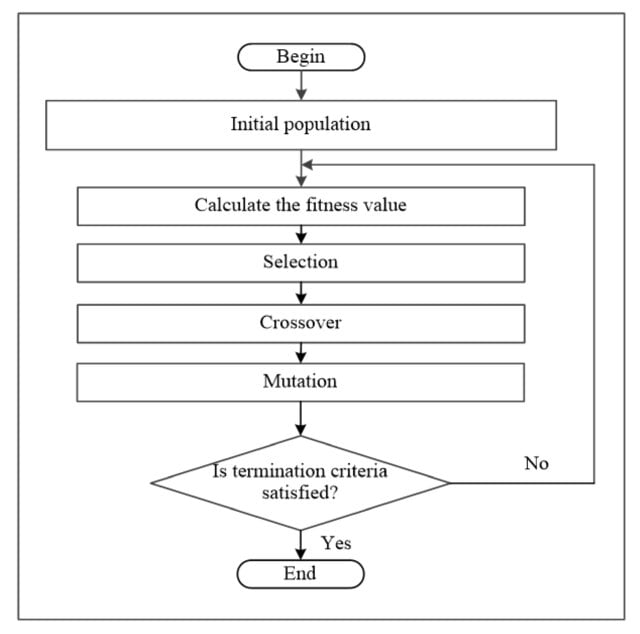

### Basic concepts

**Individual** — a single member of a population representing one specific candidate solution to the optimisation problem.

**Population** — the set of all individuals existing in a given generation (iteration) of the algorithm. The population evolves as a whole through selection, crossover, and mutation.

**Genotype** — the internal encoded representation of an individual (the data structure on which genetic operators act directly, e.g. a bit string, a vector of real numbers, or a permutation).

**Phenotype** — the decoded, explicit form of an individual in the problem space; in other words, a concrete solution ready to be evaluated (e.g. a particular route in the travelling-salesperson problem).

**Gene** — the smallest unit of information in a genome, encoding a single feature or decision variable of the problem.

**Fitness function** — a mathematical measure of the quality of an individual. It assigns each solution a numerical value describing how well it performs in the given environment. It corresponds to the objective function in conventional optimisation and forms the basis of selection pressure.

**Generation** (iteration) — one step of the main evolutionary loop in which the current population is transformed into a new population by selection and evolutionary operators.

### Selection

The selection operator creates evolutionary pressure. Its role is to choose the individuals that will become parents of the new generation, with fitter individuals having a greater probability of reproduction.

#### Random selection

Random selection is the simplest selection method. Every individual is assigned exactly the same probability of being selected, regardless of its fitness value. The method creates no selection pressure and is used mainly as a baseline in experiments or as an auxiliary mechanism for maintaining population diversity.

1. Determine the number $N$ of individuals to be selected for the parent group or new population.
2. For each of the $N$ positions in the new population, draw one individual from the current base population using uniform sampling with replacement.
3. The probability of selecting any individual $i$ is the same and equals $P(i)=\frac{1}{M}$, where $M$ is the size of the base population.
4. Stop once the required $N$ individuals have been selected.

#### Roulette-wheel selection

Roulette-wheel selection assigns each individual a selection probability directly proportional to its fitness value $f(x)$. This may lead to early domination by a "super-individual" that rapidly takes over the population and causes premature convergence. It may also reduce selection pressure in later stages, when fitness values become similar. In practice, this often leads to trapping in a local optimum.

The method can be interpreted as a roulette wheel whose sector sizes are proportional to the individuals' fitness values.

1. Compute the fitness value $f_i$, with $f_i>0$, for each of the $M$ individuals in the population.
2. For each individual $i$, compute its selection probability $p_i$ as its share of the total fitness: $p_i=\frac{f_i}{S}$, where $S=\sum_{i=1}^{M}f_i$.
3. Compute the cumulative probability $q_i$ for each individual, partitioning the interval $[0,1]$ into $M$ continuous non-overlapping subintervals: $q_i=\sum_{j=1}^{i}p_j$, for $1\leq i\leq M$.
4. Set the number of selected individuals to zero and determine the target parent-group size $N$.
5. Repeat $N$ times with replacement until the parent population is complete.
   1. In each iteration draw a pseudorandom value (the roulette pointer) $r$ uniformly from $[0,1)$.
   2. Select the individual $i$ whose interval contains $r$, i.e. $q_{i-1}\leq r\leq q_i$, with $q_0=0$.

[IMAGE_PRESERVE]

#### Stochastic Universal Sampling

Stochastic Universal Sampling (SUS) is a deterministic-random modification of classical roulette-wheel selection. Its main purpose is to reduce sampling error, i.e. situations in which the number of copies actually selected for an individual differs substantially from the expected number implied by its fitness.

The method can be interpreted as a roulette wheel with $N$ equally spaced pointers.

1. Compute the cumulative distribution $q_i$ for each individual, dividing $[0,1]$ into $M$ continuous non-overlapping intervals: $q_i=\sum_{j=1}^{i}p_j$, for $1\leq i\leq M$.
2. Compute the spacing between pointers as $\sigma=\frac{1}{N}$, where $N$ is the number of individuals to select.
3. Draw the starting value $r$ uniformly from the interval $[0,\sigma)$.
4. Compute the $N$ pointer positions: $p_k=r+(k-1)\cdot\sigma$, for $1\leq k\leq N$.
5. Select individuals by locating each $p_k$ in the corresponding individual interval.

#### Rank selection

Rank selection was designed to address two weaknesses of roulette-wheel selection: premature convergence caused by domination by "super-individuals", and decreasing selection pressure late in the run when fitness values become similar.

In rank selection, the absolute fitness value $f(x)$ is ignored. Instead, each individual receives a rank $r\in\{1,2,\ldots,N\}$ according to its position in the sorted population, where $r=1$ denotes the worst individual and $r=N$ the best. Selection probability therefore depends only on rank, ensuring stable and controllable selection pressure independently of the absolute objective-function values.

Rank selection has two common variants: linear and exponential. In the linear variant, probability increases linearly with rank, allowing smooth control of selection pressure using one parameter. In the exponential variant, probability rises exponentially with rank, strongly favouring the very best individuals and sharply reducing the chances of weaker ones.

1. Sort population $P$ by fitness value.
2. Assign each individual a rank $r\in\{1,2,\ldots,N\}$.
3. Compute the selection probability for each rank.
   1. Linear: $p(r)=\frac{1}{N}\left((2-s)+2(s-1)\frac{r-1}{N-1}\right)$, where $s\in[1,2)$ is the expected number of copies of the best individual.
   2. Exponential: $p(r)=\frac{c^{N-r}}{\sum_{j=1}^{N}c^{N-j}}=\frac{c^{N-r}(1-c)}{1-c^N}$, where $c\in(0,1)$ is the exponential scale.
4. Compute the cumulative distribution for each individual: $q_i=\sum_{j=1}^{i}p(j)$, with $q_0=0$ and $q_N=1$.
5. Create an empty parent population $P_{parents}$.
6. Repeat $N$ times:
   1. draw $u\sim U[0,1)$,
   2. find index $k$ such that $q_{k-1}\leq u<q_k$,
   3. add the individual of rank $k$ to $P_{parents}$.

#### Tournament selection

Tournament selection is one of the most popular selection methods used in genetic algorithms. It combines simple implementation, low computational complexity, and straightforward control of selection pressure. Rather than analysing the entire population at once (as roulette-wheel or rank selection does), tournament selection organises small local "tournaments". A group of $k$ individuals is sampled from the current population; the individual with the best fitness wins and is added to the parent group. The process is repeated until the new parent population is complete.

1. Choose the tournament size $k$, typically 2–5 individuals.
2. Repeat the selection loop $N$ times:
   1. sample $k$ participants uniformly,
   2. compare their fitness values $f(x)$,
   3. select the participant with the highest $f(x)$ as the winner,
   4. add the winner to the new parent population; the original individual remains in the base population and may participate in later tournaments.

The tournament size $k$ directly controls evolutionary pressure:
- $k=1$ is equivalent to completely random selection and creates no selection pressure;
- $k=2$ is the most common variant and provides moderate selection pressure, giving weaker individuals a realistic chance of survival if they happen to face an even weaker opponent;
- large $k$, e.g. $k\geq5$, creates strong selection pressure, sharply reducing the chances of weaker individuals. This accelerates convergence but increases the risk of becoming trapped in a local optimum.

### Crossover

The crossover operator combines genetic material from two (or more) parent individuals to create new solutions (offspring) that inherit characteristics from both parents. In genetic algorithms, crossover primarily supports exploration of the search space. Its fundamental role is to exchange genetic material (genes) between parents so that offspring inherit new combinations of parental characteristics.

The implementation of crossover depends directly on the chosen genome representation.

#### Operators for binary and discrete representations

1. **Single-point crossover**
- one cut point is sampled as a position in the genome;
- the offspring receives the first genome segment from the first parent and the second segment from the second parent (a second offspring can be created using the reverse combination).

[IMAGE_PRESERVE]

2. **Multi-point crossover**
- at least two cut points are sampled;
- the genome is divided into alternating segments that are exchanged between the parents. This helps avoid breaking groups of related features located near opposite ends of the genome.

[IMAGE_PRESERVE]

3. **Uniform crossover**

No cut points are defined. For each gene independently, the parent from which the gene is inherited is sampled, usually with a 50% probability for each parent.

#### Operators for real-valued representations

In continuous optimisation, where the genome is a vector of numbers $x\in\mathbb{R}^n$, simply swapping genome segments may be too disruptive. Averaging and combinatorial operators are therefore commonly used.

1. **Arithmetic / averaging crossover**

The offspring is formed as a linear combination of parent vectors $R_1$ and $R_2$:
- $\text{Offspring}_1=\alpha\times R_1+(1-\alpha)\times R_2$
- $\text{Offspring}_2=(1-\alpha)\times R_1+\alpha\times R_2$

where $\alpha\in[0,1]$ may be a fixed value or a value sampled independently for each gene.

2. **Blend crossover (BLX-$\alpha$)**

This operator can generate values outside the interval directly spanned by the parents. A new gene value $x$ is sampled from the extended interval $[x_{min}-I\times\alpha, x_{max}+I\times\alpha]$, where:
- $I=|x_1-x_2|$,
- $\alpha$ is the extension parameter, commonly $\alpha=0.5$.

### Mutation

The mutation operator introduces random, usually small, changes into the genome of a single individual with some typically low probability. Mutation introduces new genetic variation into the population and supports local diversification of the search. Whereas crossover explores the search space by recombining characteristics that already exist in the parents, mutation can introduce values or combinations that are currently absent. This helps preserve genetic diversity and protects the algorithm against premature convergence to a local optimum.

The implementation of mutation depends directly on the chosen genome representation.

#### Operators for binary representations

1. **Bit-flip mutation**

For each gene (bit) in the genome, a value is sampled from a uniform distribution. If the value is smaller than $p_m$, the bit is flipped: $1\rightarrow0$ or $0\rightarrow1$.

2. **Single-point mutation**

Instead of testing every bit independently, exactly one position (locus) in the genome is sampled and the bit at that position is flipped.

#### Operators for real-valued representations

When the genome is a vector of real values $x\in\mathbb{R}^n$, simply replacing values may be too disruptive or inefficient. Arithmetic modifications are therefore used.

1. **Gaussian mutation**

A random variable following the normal distribution $N(0,\sigma)$ is added to the selected gene: $x_i' = x_i + N(0,\sigma)$, where the standard deviation $\sigma$ controls the mutation range.

2. **Uniform mutation**

The value of the selected gene is replaced with a new number drawn uniformly from the allowed interval $[x_{min},x_{max}]$.

3. **Non-uniform / creep mutation**

The gene is modified by a small random value whose range decreases as the number of generations increases. This supports precise local optimisation during the final stages of the algorithm.

## Genetic algorithms in the modern toolset

A wide range of genetic-algorithm implementations is available in Python. One of the most popular libraries is [PyGAD](https://github.com/ahmedfgad/GeneticAlgorithmPython). It was designed primarily for ease of use: it allows quick configuration of the search space, population size, number of generations, and crossover, mutation, and selection parameters. The library also makes it easy to define custom fitness functions and work with different data representations.

One of PyGAD's major advantages is its native support for machine-learning and neural-network problems. The package provides dedicated modules for optimising neural-network weights, enabling neuroevolution as an alternative to conventional gradient-based training. It also integrates readily with popular libraries such as Keras and PyTorch and makes it straightforward to modify parameters during evolution or visualise convergence progress.

### Example 1: maximising a two-variable function

The objective is to find the maximum of the following function: $f(x,y)=sin(x)\times cos(y)+exp(-\frac{x^2+y^2}{10})$.

In [ ]:
from IPython.display import HTML

In [ ]:
import pygad
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [ ]:
from collections.abc import Iterable
from typing import Any

Define the objective function to be maximised.

In [ ]:
def objective_function(x: float, y: float) -> float:
    return np.sin(x) * np.cos(y) + np.exp(-(x**2 + y**2) / 10.0)

Define the fitness function as an adapter for the objective function.

In [ ]:
def fitness_func(ga_instance: Any, solution: Iterable, solution_idx: Any) -> float:
    x, y = solution[0], solution[1]
    return objective_function(x, y)

Auxiliary callback that captures and stores population positions in every generation of the algorithm.

In [ ]:
population_history = []

In [ ]:
def on_generation(ga_instance: Any) -> None:
    population_history.append(ga_instance.population.copy())

Configure the genetic algorithm.

In [ ]:
ga_instance = pygad.GA(
    num_generations=50,             # number of generations
    num_parents_mating=10,          # number of parents selected for crossover
    fitness_func=fitness_func,      # defined fitness function
    sol_per_pop=40,                 # 40 individuals in the population
    num_genes=2,                    # two variables, x and y — genome length
    init_range_low=-5.0,            # lower initial range for gene values
    init_range_high=5.0,            # upper initial range for gene values
    random_mutation_min_val=-0.5,   # lower mutation range
    random_mutation_max_val=0.5,    # upper mutation range
    parent_selection_type="tournament",  # tournament selection
    K_tournament=3,                 # tournament size
    crossover_type="single_point",  # single-point crossover
    mutation_type="random",         # random mutation
    mutation_percent_genes=50,      # probability of gene mutation (%)
    gene_space=[                    # allowed gene-value range (analogous to random_mutation_min_val / max)
        {"low": -5.0, "high": 5.0},
        {"low": -5.0, "high": 5.0},
    ],
    on_generation=on_generation,    # callback executed internally after each generation
)

Store the initial population positions.

In [ ]:
population_history.append(ga_instance.initial_population.copy())

Run the evolution process.

In [ ]:
ga_instance.run()

Obtain the best solution.

In [ ]:
solution, solution_fitness, _ = ga_instance.best_solution()

In [ ]:
print(f"Maximum found at point (x, y): ({solution[0]:.4f}, {solution[1]:.4f})")
print(f"Function value at this point: {solution_fitness:.4f}")

Visualisation of the optimisation process.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

x_grid = np.linspace(-5, 5, 200)
y_grid = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x_grid, y_grid)
Z = objective_function(X, Y)

contour = ax.contourf(X, Y, Z, levels=30, cmap="viridis")
fig.colorbar(contour, label="Value of $f(x, y)$")

scat = ax.scatter([], [], c="red", edgecolors="white", s=50, label="Individuals (genes)")
title = ax.set_title("")

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_xlabel("Gen X")
ax.set_ylabel("Gen Y")
ax.legend(loc="upper left")


# Animation initialisation function
def init() -> tuple:
    scat.set_offsets(np.empty((0, 2)))
    return scat, title

# Function updating an animation frame
def update(frame):
    pop = population_history[frame]
    scat.set_offsets(pop[:, :2])
    title.set_text(f"Generation {frame}/{len(population_history)-1}")
    return scat, title


ani = FuncAnimation(
    fig, update, frames=len(population_history),
    init_func=init, interval=150, blit=True, repeat=True
)

plt.tight_layout()
plt.close()
HTML(ani.to_jshtml())

### Example 2: minimising a six-parameter function

Let us find an optimal set of six parameters ($x_1$–$x_6$) that minimises the difference with respect to the equation:
$11x_1+2.2x_2+(-0.7)x_3+4x_4+8.9x_5+(-1)x_6=44$.

Inputs and output of the function being optimised.

In [ ]:
function_inputs = [11, 2.2, -0.7, 4, 8.9, -1]
desired_output = 44

Define the fitness function.

In [ ]:
def fitness_func(ga_instance: Any, solution: Iterable, solution_idx: Any) -> float:
    # output for the given individual
    output = np.sum(solution * function_inputs)
    # fitness value based on absolute error
    fitness = 1.0 / (np.abs(output - desired_output) + 0.000001)
    return fitness

Configure the heuristic — the genetic algorithm.

In [ ]:
ga_instance = pygad.GA(
    num_generations=100,             # number of generations
    num_parents_mating=4,            # number of parents selected for crossover
    fitness_func=fitness_func,       # defined fitness function
    sol_per_pop=10,                  # population size (number of individuals)
    num_genes=len(function_inputs),  # genome length (number of variables)
    init_range_low=-10,              # lower initial range for gene values
    init_range_high=10,              # upper initial range for gene values
    parent_selection_type="tournament", # tournament selection
    K_tournament=3,                  # tournament size
    crossover_type="single_point",   # single-point crossover
    mutation_type="random",          # random mutation
    mutation_percent_genes=20,       # probability of gene mutation (%)
)

Run the evolution process.

In [ ]:
ga_instance.run()

Results

In [ ]:
solution, solution_fitness, solution_idx = ga_instance.best_solution()

In [ ]:
print(f"Best solution found (genome): {solution}")
print(f"Fitness value: {solution_fitness}")

Verify the result.

In [ ]:
calculated_output = np.sum(solution * function_inputs)

In [ ]:
calculated_output.item()

Algorithm convergence plot.

In [ ]:
ga_instance.plot_fitness(title="PyGAD algorithm convergence", save_dir=None)

### Example 3: array partitioning

Suppose the input is a vector of numerical values, e.g. $[2,10,3,8,5,7,9,5,3,2]$. The objective is to partition the input vector so that the sums of the two sub-vectors are equal, for example $[2,10,3,5,7]$ and $[8,9,5,3,2]$.

Define the list (array) to be partitioned.

In [ ]:
input_values = [2, 10, 3, 8, 5, 7, 9, 5, 3, 2]

In [ ]:
input_sum = np.sum(input_values)

Define the partitioning and fitness functions.

In [ ]:
def binary_split(values: Iterable, binary_pos: Iterable) -> np.ndarray:
    subvec = np.array(values)[np.array(binary_pos) == 1]

    return subvec

In [ ]:
def fitness_func(ga_instance: Any, solution: Iterable, solution_idx: Any) -> float:
    subvec = binary_split(input_values, solution)
    subvec_sum = np.sum(subvec)

    # normalise the value to the 0–1 range
    fitness = 1 - np.abs(input_sum - 2 * subvec_sum) / input_sum

    return fitness.item()

Configure the heuristic.

In [ ]:
ga_instance = pygad.GA(
    num_generations=30,
    gene_space=[0, 1],               # gene-value space — binary
    fitness_func=fitness_func,       # defined fitness function
    sol_per_pop=10,                  # population size (fixed number of individuals)
    num_genes=len(input_values),     # genome length (number of variables)
    num_parents_mating=5,            # number of parents
    keep_parents=2,                  # number of solutions to retain
    parent_selection_type="tournament", # tournament selection
    K_tournament=3,                  # tournament size
    crossover_type="single_point",   # single-point crossover
    mutation_type="random",          # random mutation
    mutation_percent_genes=10,        # probability of gene mutation (%)
    stop_criteria="reach_1",         # stop the search when the fitness value reaches 1
)

Run the evolution process.

In [ ]:
ga_instance.run()

Obtain the best results.

In [ ]:
solution, solution_fitness, solution_idx = ga_instance.best_solution()

In [ ]:
solution, solution_fitness.item(), solution_idx.item()

### Example 4: the knapsack problem

The knapsack problem is one of the classic optimisation problems. The objective is to fill a knapsack with limited carrying capacity using items whose total value is as large as possible.

For example, suppose the available items are:
1. Jacket. Weight: 2 kg, value: $4.
2. Sleeping bag. Weight: 3 kg, value: $5.
3. Camera. Weight: 1 kg, value: $3.
4. Tent. Weight: 4 kg, value: $7.

The maximum carrying capacity is 5 kg. What is the most valuable choice? The camera (1 kg) and the tent (4 kg), giving a total value of $10.

In [ ]:
# key, [item, value, weight]
items = {
    1: ["Generator", 100, 7],
    2: ["Hi-Fi system", 300, 7],
    3: ["Sleeping bag", 300, 10],
    4: ["Laptop", 500, 5],
    5: ["TV decoder", 200, 6],
    6: ["Radio", 40, 2],
    7: ["Oxygen apparatus", 300, 15],
    8: ["Charger", 70, 6],
    9: ["Thermal mug", 250, 3],
    10: ["Tent", 280, 3],
    11: ["Thermos flask", 100, 1],
}

In [ ]:
max_weight = 25

In [ ]:
value_sum = sum([x[1] for x in items.values()])

Total value of all items: 2440; total weight: 65.

Define the fitness function.

In [ ]:
def fitness_func(ga_instance: Any, solution: Iterable, solution_idx: Any) -> float:
    total_value = 0
    total_weight = 0

    for i in range(len(items)):
        if solution[i] == 0:
            continue

        total_value += items[i + 1][1]
        total_weight += items[i + 1][2]

        # weight constraint
        if total_weight > 25:
            return float("-inf")

    return total_value / value_sum

Configure the heuristic.

In [ ]:
ga_instance = pygad.GA(
    num_generations=100,
    gene_space=[0, 1],
    num_parents_mating=15,
    fitness_func=fitness_func,
    sol_per_pop=40,
    num_genes=11,
    parent_selection_type="tournament",
    crossover_type="single_point",
    mutation_type="random",
    mutation_probability=0.02,
)

Run the evolution process.

In [ ]:
ga_instance.run()

Solutions

In [ ]:
solution, solution_fitness, solution_idx = ga_instance.best_solution()

In [ ]:
{items[item_id][0]: items[item_id][1:] for item_id in items if item_id in np.array(list(items.keys()))[solution == 1]}